In [33]:
import seaborn as sns
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [2]:
peng_data =sns.load_dataset('penguins')

In [3]:
peng_data


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [11]:
## Will be using island data here to test if it is a strong label or not

label = 'species'
feature= [i for i in peng_data.columns if i!=label]
X = peng_data[feature]
y = peng_data[label]
num_cols = [i for i in feature if X[i].dtype in ['int64','float64']]
cat_cols = [i for i in feature if i not in set(num_cols)]
x = 0
class_names  = [i for i in {i:x+1 for i in peng_data[label]}.keys()]

label_enc = LabelEncoder()


In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=1)
label_enc.fit(y_train)
y_train = label_enc.transform(y_train)
y_test = label_enc.transform(y_test)
y_train

array([1, 0, 2, 1, 0, 1, 2, 2, 0, 1, 1, 0, 2, 1, 2, 2, 1, 0, 2, 0, 2, 1,
       2, 0, 2, 2, 0, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 0, 2, 1, 1, 2, 0,
       0, 0, 0, 1, 2, 0, 1, 0, 2, 1, 1, 0, 2, 0, 2, 1, 0, 2, 0, 2, 2, 2,
       0, 0, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 1, 0, 0, 0, 2, 1, 2, 2, 2, 2,
       1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 0, 2, 1, 2,
       0, 0, 2, 2, 2, 0, 1, 2, 0, 2, 2, 2, 0, 2, 1, 0, 2, 2, 0, 1, 2, 1,
       1, 1, 2, 2, 1, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 0, 1, 0, 2, 1,
       1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0, 1,
       0, 2, 0, 2, 0, 0, 2, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 2, 2, 0, 1,
       0, 1, 2, 0, 1, 2, 2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 0, 0, 0, 0, 2, 0,
       0, 2, 0, 0, 0, 2, 1, 2, 1, 0, 2, 0, 2, 2, 0, 0, 0, 2, 1, 0, 0, 1,
       2, 2, 2, 1, 2, 2, 0, 0, 0, 2, 0, 1, 2, 0, 2, 0])

In [18]:
num_transformer = Pipeline(steps=[
        ('imputing',SimpleImputer(strategy='mean')),
        ('scale',MinMaxScaler())
])

categ_transformer = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
     ('OneHotEncode',OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('num',num_transformer,num_cols),
    ('categ',categ_transformer,cat_cols)
])

In [19]:
logistic_model = LogisticRegression(random_state=1)
model_pipe = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',logistic_model)
])
model_pipe.fit(X_train,y_train)

/Users/kailasnathr/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/kailasnathr/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/kailasnathr/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/kailasnathr/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/kailasnathr/Library/Python/3.9/lib/python/site-packages/sklearn

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputing',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('categ',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHotEncode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['island', 'sex'])])),
                ('model', LogisticRegression(random_state=1))])

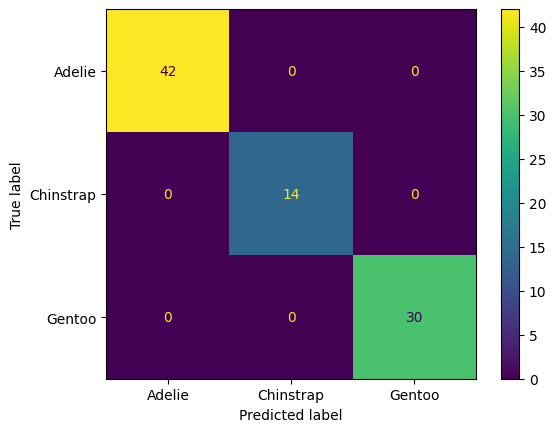

In [20]:
pred = model_pipe.predict(X_test)
cm = confusion_matrix(y_test,pred,labels=logistic_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot()

#### Here using island feature makes it incredibly easy to predict the species of our penguins thus showing that it is a strong feature

In [25]:
## Will not be using island data here 

label1 = 'species'
list_exclude = ['island',label]
feature1= [i for i in peng_data.columns if i not in set(list_exclude)]
X1 = peng_data[feature1]
y1 = peng_data[label1]
num_cols1 = [i for i in feature1 if X1[i].dtype in ['int64','float64']]
cat_cols1 = [i for i in feature1 if i not in set(num_cols1)]
x1 = 0
class_names1  = [i for i in {i:x+1 for i in peng_data[label1]}.keys()]

X_train1,X_test1,y_train1,y_test1 = train_test_split(X1,y1,random_state=1)


In [27]:
le = LabelEncoder()
le.fit(y_train1)
y_train1 = label_enc.transform(y_train1)
y_test1 = label_enc.transform(y_test1)




ValueError: y contains previously unseen labels: 1

In [29]:
num_trans = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='mean')),
        ('scale',MinMaxScaler())
    ]
)

cate_trans = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('onehotencode',OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num_col',num_trans,num_cols1),
        ('cate_cols',cate_trans,cat_cols1)
    ]
)

In [30]:
model1 = LogisticRegression(random_state=1)

model_pipe1 = Pipeline(
    steps=[
        ('preprocess',preprocessor1),
        ('model',model1)
    ]
)
model_pipe1.fit(X_train1,y_train1)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_col',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cate_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex'])])),
                ('model', LogisticRegression(random_state=1))])

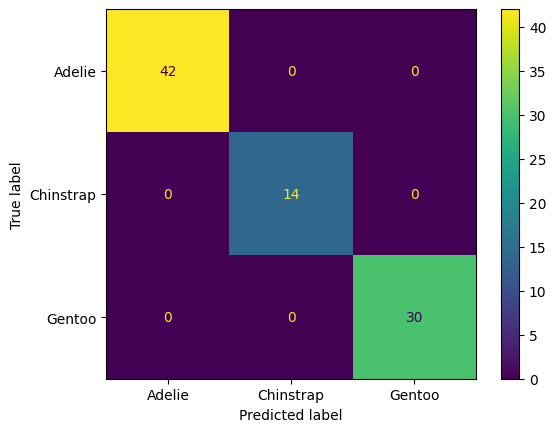

In [32]:
pred1 = model_pipe1.predict(X_test1)
cm1 = confusion_matrix(y_test1,pred1,labels=logistic_model.classes_)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=class_names1)
disp.plot()

##### Although island provides perfect classification, similar performance without it suggests that the dataset is inherently well-separated. This indicates that multiple features strongly correlate with species, and the problem may be simpler than expected.